<a href="https://colab.research.google.com/github/karanmunjal1900/codealpha_task1/blob/main/credit_scoring_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 1 - CREDIT SCORING MODEL**


Objective: Predict an individual's creditworthiness using past financial data.

Approach: Use classification algorithms like Logistic Regression, Decision Tree, and Random Forest.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving credit_scoring_model.pkl to credit_scoring_model.pkl
Saving credit.csv to credit.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv("credit.csv")
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,job,dependents,telephone,foreign_worker,default
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,skilled employee,1,yes,yes,1
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,skilled employee,1,none,yes,2
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,1
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,skilled employee,2,none,yes,1
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,skilled employee,2,none,yes,2


In [4]:
print(df.shape)
df.info()
df.describe()

(1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_length     1000 non-null   object
 7   installment_rate      1000 non-null   int64 
 8   personal_status       1000 non-null   object
 9   other_debtors         1000 non-null   object
 10  residence_history     1000 non-null   int64 
 11  property              1000 non-null   object
 12  age                   1000 non-null   int64 
 13  installment_plan      1000 non-null   object
 14  housing               1000 non-null   object
 15  existing_credits      1000 n

,months_loan_duration,amount,installment_rate,residence_history,age,existing_credits,dependents,default
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


Missing Values:

In [5]:
print(df.isnull().sum())

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_length       0
installment_rate        0
personal_status         0
other_debtors           0
residence_history       0
property                0
age                     0
installment_plan        0
housing                 0
existing_credits        0
job                     0
dependents              0
telephone               0
foreign_worker          0
default                 0
dtype: int64


Check Target Variable:


In [6]:
print(df["default"].value_counts())

default
1    700
2    300
Name: count, dtype: int64


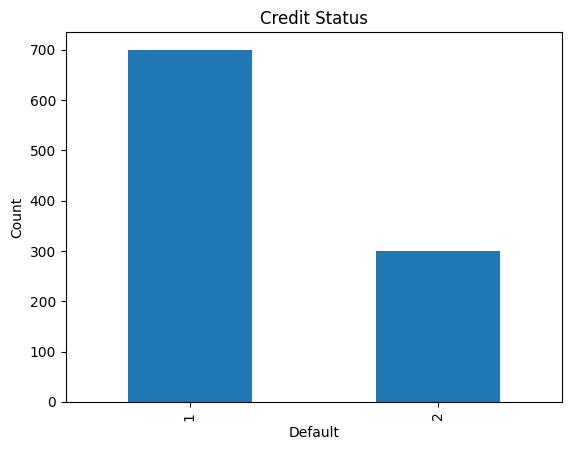

In [7]:
df["default"].value_counts().plot(kind="bar")
plt.title("Credit Status")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

Feature Engineering:

In [8]:
df["default"] = df["default"].map({
    1:0,
    2:1
})    #Here; 0 = Good Credit, 1 = Bad Credit

Encode Categorical Columns:

In [9]:
label_encoder = LabelEncoder()
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = label_encoder.fit_transform(df[column])

In [10]:
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,job,dependents,telephone,foreign_worker,default
0,1,6,0,7,1169,4,3,4,3,2,...,2,67,1,1,2,1,1,1,1,0
1,0,48,4,7,5951,2,1,2,1,2,...,2,22,1,1,1,1,1,0,1,1
2,3,12,0,4,2096,2,2,2,3,2,...,2,49,1,1,1,3,2,0,1,0
3,1,42,4,5,7882,2,2,2,3,1,...,0,45,1,0,1,1,2,0,1,0
4,1,24,1,1,4870,2,1,3,3,2,...,3,53,1,0,2,1,2,0,1,1


Separate Features and Target:

In [11]:
X = df.drop("default", axis=1)
y = df["default"]

Train-Test Split:


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Feature Scaling:

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Logistic Regression:

In [14]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

Train Decision Tree:

In [15]:
dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

Train Random Forest:

In [16]:
rf = RandomForestClassifier(
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

Evaluate Models:

In [17]:
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision :", precision_score(y_test, lr_pred))
print("Recall :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC :", roc_auc_score(y_test, lr_prob))

Logistic Regression
Accuracy : 0.725
Precision : 0.5588235294117647
Recall : 0.3220338983050847
F1 Score : 0.40860215053763443
ROC AUC : 0.7256881836759226


In [18]:
print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision :", precision_score(y_test, dt_pred))
print("Recall :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC AUC :", roc_auc_score(y_test, dt_prob))

Decision Tree
Accuracy : 0.655
Precision : 0.421875
Recall : 0.4576271186440678
F1 Score : 0.43902439024390244
ROC AUC : 0.5976078855631687


In [19]:
print("Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC :", roc_auc_score(y_test, rf_prob))

Random Forest
Accuracy : 0.785
Precision : 0.7222222222222222
Recall : 0.4406779661016949
F1 Score : 0.5473684210526316
ROC AUC : 0.8093520855872101


Confusion Matrix:

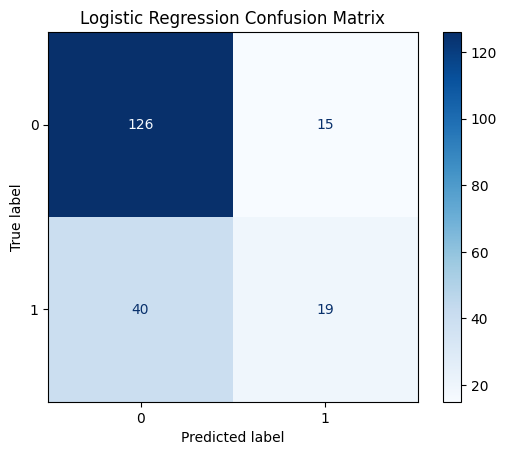

In [20]:
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

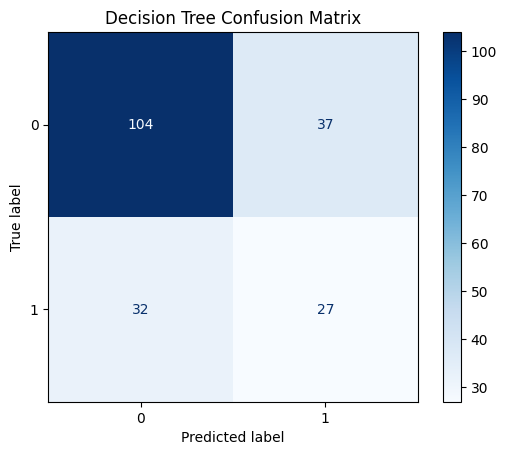

In [21]:
cm = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

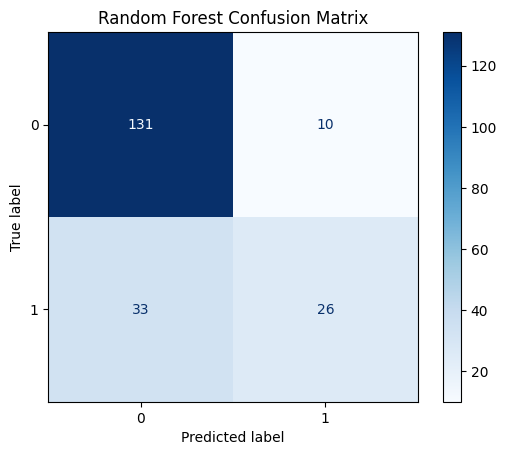

In [22]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

Compare All Models:

In [23]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.725   0.558824  0.322034  0.408602
1        Decision Tree     0.655   0.421875  0.457627  0.439024
2        Random Forest     0.785   0.722222  0.440678  0.547368


Accuracy Comparison Graph:

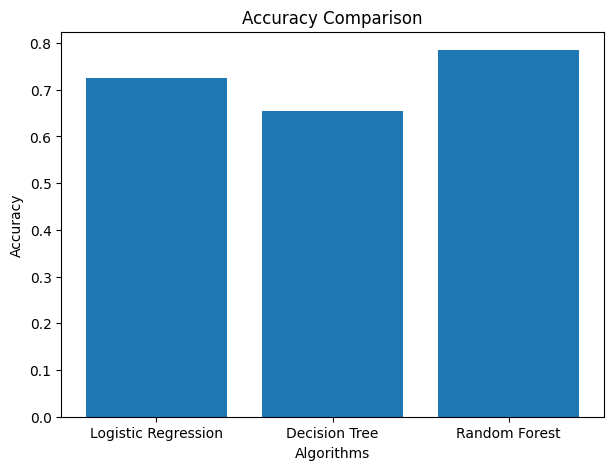

In [24]:
plt.figure(figsize=(7,5))
plt.bar(
    results["Model"],
    results["Accuracy"]
)
plt.title("Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

Feature Importance (Random Forest):

In [25]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print(importance)

                 Feature  Importance
4                 amount    0.128527
12                   age    0.110038
0       checking_balance    0.107979
1   months_loan_duration    0.091594
3                purpose    0.068137
6      employment_length    0.052276
2         credit_history    0.050272
7       installment_rate    0.048210
11              property    0.045921
5        savings_balance    0.045761
10     residence_history    0.042670
8        personal_status    0.037203
16                   job    0.031163
13      installment_plan    0.030892
14               housing    0.026802
15      existing_credits    0.024339
18             telephone    0.022692
9          other_debtors    0.019204
17            dependents    0.012016
19        foreign_worker    0.004303


PROJECT CONCLUSION:

Credit Scoring was performed using three machine learning algorithms.
The algorithms used were Logistic Regression, Decision Tree, Random Forest.

After evaluating all models, the Random Forest algorithm achieved the highest accuracy and is selected as the final prediction model.

In [26]:
import joblib
joblib.dump(
    rf,
    "credit_scoring_model.pkl"
)

['credit_scoring_model.pkl']

In [27]:
from google.colab import files
files.download(
    "credit_scoring_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>